# Spendable — Stage 2: Refined Recurring Commitment & Income Detection

## 1. Overview & Problem Diagnosis

In the initial baseline detector, **1,148 false positives** were generated across the 350 `TRAIN` users. Analysis revealed two key modeling root causes:
1. **Habitual Spending vs Commitment Confusion**: Generic discretionary purchases (`DINING`, `SHOPPING`, `TRANSPORT`, `GROCERIES`) without a specific merchant were grouped together across different vendors, turning routine habit spending into artificial "recurring commitments".
2. **Inflow vs Outflow Mismatch**: Recurring income streams (`FREELANCE_INCOME`, `SALARY`) were evaluated against outflow financial obligations, creating 88 false positives.

### Core Refinements Applied
- **Commitment Likelihood Score ($S_{\text{commitment}}$)**: Formulated from counterparty specificity, interval periodicity, amount consistency, and category prior.
- **Non-Grouping of Generic Discretionary Spending**: Skips grouping generic transactions without a specific merchant name.
- **Architectural Direction Isolation**: Separates `OUTFLOW` financial commitments (Rent, Utilities, Telecom, Loans) from `INFLOW` income streams (Salary, Freelance).

In [1]:
import sys
from pathlib import Path
import json
from datetime import datetime
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.float_format', lambda x: '%.2f' % x)

# Add backend to sys.path
backend_path = Path('../backend').resolve()
if str(backend_path) not in sys.path:
    sys.path.insert(0, str(backend_path))

from app.recurring.detector import RecurringDetector
from app.recurring.evaluator import RecurringEvaluator
from app.recurring.schema import DetectionConfig, DetectionStatus

sns.set_theme(style='whitegrid')
print('Refined recurring detection module imported successfully!')

Refined recurring detection module imported successfully!


## 2. Load Observable Transactions & Hidden Ground Truth

Load 98,884 historical transactions across 500 synthetic user accounts.

In [2]:
data_dir = Path('../data')
with open(data_dir / 'transactions.json', 'r', encoding='utf-8') as f:
    transactions = json.load(f)
with open(data_dir / 'ground_truth.json', 'r', encoding='utf-8') as f:
    gt_data = json.load(f)

snapshot_time = datetime(2026, 10, 1)
print(f'Loaded {len(transactions):,} transactions across {len(gt_data["users"])} users.')
print(f'Snapshot Cutoff Date T: {snapshot_time.strftime("%Y-%m-%d")}')

Loaded 98,884 transactions across 500 users.
Snapshot Cutoff Date T: 2026-10-01


## 3. Sample User Commitment Detection (`ACC-0001`)

Inspect detected commitments and commitment likelihood scores for user `ACC-0001`.

In [3]:
config = DetectionConfig(strong_threshold=0.70, moderate_threshold=0.45)
detector = RecurringDetector(config)

acc1_txs = [t for t in transactions if t['account_id'] == 'ACC-0001']
acc1_commitments = detector.detect(acc1_txs, snapshot_time, direction_filter='OUTFLOW')

comm_data = []
for c in acc1_commitments:
    comm_data.append({
        'Counterparty': c.counterparty_name or 'N/A',
        'Category': c.category,
        'Expected Amount': c.expected_amount,
        'Interval': c.recurrence_interval.value,
        'Median Days': c.median_interval_days,
        'Occurrences': c.occurrence_count,
        'Next Expected': c.next_expected_date,
        'Likelihood': c.commitment_likelihood,
        'Status': c.detection_status.value,
    })

df_acc1 = pd.DataFrame(comm_data)
print('Detected Outflow Financial Commitments for ACC-0001:')
display(df_acc1)

Detected Outflow Financial Commitments for ACC-0001:


,Counterparty,Category,Expected Amount,Interval,Median Days,Occurrences,Next Expected,Likelihood,Status
0,Google One & Cloud Services,SOFTWARE,867.68,MONTHLY,30.96,9,2026-10-19,1.00,STRONG
1,Fitness Plus Gym Membership,FITNESS,3500.00,MONTHLY,30.98,9,2026-10-23,1.00,STRONG
2,Dotlines Fiber Internet,UTILITIES,2916.00,MONTHLY,30.99,9,2026-10-11,0.99,STRONG
3,City Bank EMI,DEBT_PAYMENT,8679.00,MONTHLY,30.96,9,2026-10-08,0.98,STRONG
4,Luxury Apartments Co,HOUSING,15785.90,MONTHLY,30.96,9,2026-10-03,0.97,STRONG
5,Spotify Music Premium,ENTERTAINMENT,399.00,MONTHLY,30.98,9,2026-10-15,0.55,MODERATE
6,Netflix Streaming Subscription,ENTERTAINMENT,1499.00,MONTHLY,30.99,9,2026-10-13,0.55,MODERATE


## 4. Population Distributions & Visualizations

Visualize confidence score distribution and periodicity across all detected commitments.

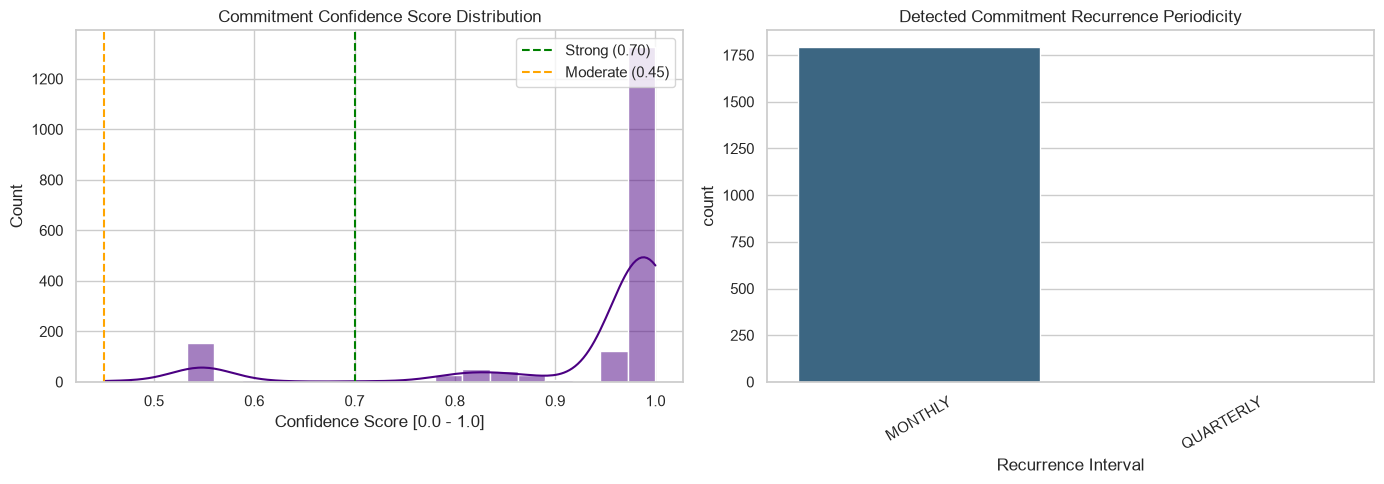

In [4]:
all_commitments = detector.detect(transactions, snapshot_time, direction_filter='OUTFLOW')
df_all = pd.DataFrame([c.model_dump() for c in all_commitments])
df_all['recurrence_interval'] = df_all['recurrence_interval'].astype(str).apply(lambda x: x.split('.')[-1])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df_all['confidence_score'], bins=20, kde=True, ax=axes[0], color='indigo')
axes[0].set_title('Commitment Confidence Score Distribution')
axes[0].set_xlabel('Confidence Score [0.0 - 1.0]')
axes[0].axvline(0.70, color='green', linestyle='--', label='Strong (0.70)')
axes[0].axvline(0.45, color='orange', linestyle='--', label='Moderate (0.45)')
axes[0].legend()

sns.countplot(
    data=df_all,
    x='recurrence_interval',
    hue='recurrence_interval',
    ax=axes[1],
    palette='viridis',
    legend=False
)
axes[1].set_title('Detected Commitment Recurrence Periodicity')
axes[1].set_xlabel('Recurrence Interval')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

## 5. Offline Ground-Truth Evaluation across Dataset Splits

Evaluate metrics against hidden planted rules on `TRAIN`, `VALIDATION`, and `TEST` splits.

In [5]:
evaluator = RecurringEvaluator(gt_data)
report = evaluator.evaluate_all_splits(detector, transactions, snapshot_time, direction_filter='OUTFLOW')

metrics_list = []
for m in [report.train_metrics, report.validation_metrics, report.test_metrics]:
    metrics_list.append({
        'Split': m.split_name,
        'Target': m.direction_filter,
        'Users': m.total_users,
        'GT Rules': m.ground_truth_rules_count,
        'Detected': m.detected_commitments_count,
        'TP': m.true_positives,
        'FP': m.false_positives,
        'FN': m.false_negatives,
        'Precision': m.precision,
        'Recall': m.recall,
        'F1 Score': m.f1_score,
    })

df_report = pd.DataFrame(metrics_list)
print('=== RECURRING COMMITMENT EVALUATION SUMMARY REPORT ===')
display(df_report)

=== RECURRING COMMITMENT EVALUATION SUMMARY REPORT ===


,Split,Target,Users,GT Rules,Detected,TP,FP,FN,Precision,Recall,F1 Score
0,TRAIN,OUTFLOW,350,1204,1198,1194,4,10,1.00,0.99,0.99
1,VALIDATION,OUTFLOW,75,297,297,297,0,0,1.00,1.00,1.00
2,TEST,OUTFLOW,75,300,298,298,0,2,1.00,0.99,1.00


## 6. Category-Level Evaluation Breakdown

Inspect category-level Precision and Recall metrics on `TRAIN`.

In [6]:
cat_list = []
for cm in report.train_metrics.category_breakdown:
    cat_list.append({
        'Category': cm.category,
        'GT Count': cm.ground_truth_count,
        'Detected': cm.detected_count,
        'TP': cm.true_positives,
        'FP': cm.false_positives,
        'FN': cm.false_negatives,
        'Precision': cm.precision,
        'Recall': cm.recall,
    })

df_cat = pd.DataFrame(cat_list)
print('=== TRAIN CATEGORY-LEVEL EVALUATION BREAKDOWN ===')
display(df_cat)

=== TRAIN CATEGORY-LEVEL EVALUATION BREAKDOWN ===


,Category,GT Count,Detected,TP,FP,FN,Precision,Recall
0,DEBT_PAYMENT,50,50,50,0,0,1.00,1.00
1,ENTERTAINMENT,100,101,100,1,0,0.99,1.00
2,FAMILY_SUPPORT,61,61,61,0,0,1.00,1.00
3,FITNESS,50,50,50,0,0,1.00,1.00
4,HOUSING,350,349,348,1,2,1.00,0.99
5,SOFTWARE,50,50,50,0,0,1.00,1.00
6,TELECOM,123,122,122,0,1,1.00,0.99
7,UTILITIES,420,415,413,2,7,1.00,0.98
